In [13]:
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])
import pyfar as pf
from FastBEMT.TorchBPM import BPM
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [14]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=50,
)

In [15]:
x_range = np.linspace(-5.0, 5.0, 30)
y_range = np.linspace(0, 5.0, 12)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    propeller_geometry=blade_dict,
    params=params,
)

propeller.run_bemt(v_inf=0.0)

In [16]:
propeller.run_compact_f1a(observer_positions=r_observers, device='cuda')
third_octave_freqs = pf.dsp.filter.fractional_octave_frequencies(num_fractions=3, frequency_range=(20,20000))[0]

In [17]:
bpm = BPM(propeller=propeller, frequencies=third_octave_freqs, device='cuda')
bpm.run_bpm(lt=1e6)

In [18]:
f1a_spl_3oct = []
n_o = propeller.spl.shape[1]
for fc in third_octave_freqs:
    f_low, f_high = fc / (2 ** (1 / 6)), fc * (2 ** (1 / 6))
    mask = (propeller.freq[:, 0] >= f_low) & (propeller.freq[:, 0] < f_high)
    if np.any(mask):
        p_band = np.sum(10 ** (propeller.spl[mask, :] / 10), axis=0)
        f1a_spl_3oct.append(10 * np.log10(p_band))
    else:
        f1a_spl_3oct.append(np.full(n_o, -np.inf))
f1a_spl_3oct = np.array(f1a_spl_3oct)

In [19]:
L_total = 10 * np.log10(
    10 ** (f1a_spl_3oct / 10)
    + 10 ** (bpm.spl_lbl.cpu().numpy() / 10)
    + 10 ** (bpm.spl_tbl.cpu().numpy() / 10)
    + 10 ** (bpm.spl_teb.cpu().numpy() / 10)
    + 10 ** (bpm.spl_ti.cpu().numpy() / 10)
    + 10 ** (bpm.spl_tip.cpu().numpy() / 10)
)

In [20]:
L_grid = L_total.reshape(30, 12, 30)
blade_passing_freq = 1 / params.blade_passing_period

In [21]:
OSPL_grid = 10 * np.log10(np.sum(10**(L_grid[third_octave_freqs >= 0.9*blade_passing_freq] / 10), axis=0))

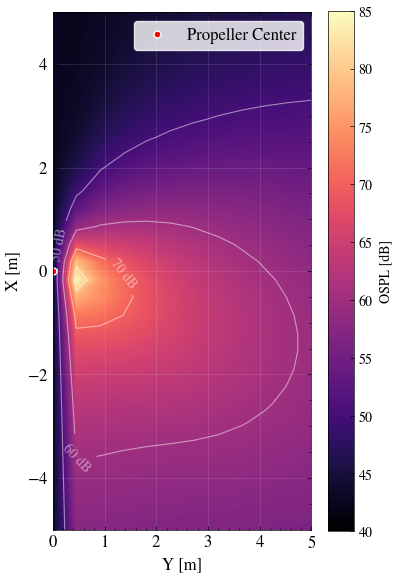

In [22]:
fig, ax = plt.subplots(figsize=(4, 6))
vmin, vmax = 40, 85
smooth_levels = np.linspace(vmin, vmax, 1000)
cf = ax.contourf(Y, X, OSPL_grid, levels=smooth_levels, cmap='magma')
cbar = fig.colorbar(cf, ax=ax, ticks=np.arange(vmin, vmax + 5, 5))
cbar.set_label('OSPL [dB]')

# 4. (Optional) Sync the contour lines with the new range
line_levels = np.arange(vmin, vmax + 5, 10)
contours = ax.contour(Y, X, OSPL_grid, levels=line_levels, colors='white', linewidths=0.8, alpha=0.5)
ax.clabel(contours, inline=True, fontsize=10, fmt='%1.0f dB')

ax.plot(0, 0, 'ro', markersize=5, label='Propeller Center', markeredgecolor='white')

ax.set_xlabel('Y [m]', fontsize=12)
ax.set_ylabel('X [m]', fontsize=12)

ax.set_aspect('equal')
ax.grid(True, alpha=0.15, color='white')
plt.legend(fontsize=12, frameon=True, edgecolor='white')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
from shapely.geometry import Polygon, box

target_level = 60.0
weight_below = 2.0  # Weight for the area where X < 0
weight_above = 1.0  # Weight for the area where X >= 0

specific_contour = ax.contour(Y, X, OSPL_grid, levels=[target_level])
bottom_half_box = box(-5.0, -5.0, 5.0, 0.0) 
top_half_box = box(-5.0, 0.0, 5.0, 5.0)

area_above = 0.0
area_below = 0.0

for path in specific_contour.get_paths():
    vertices = path.vertices
    if len(vertices) > 3:
        poly = Polygon(vertices)
        
        poly_below = poly.intersection(bottom_half_box)
        poly_above = poly.intersection(top_half_box)
        
        area_below += poly_below.area
        area_above += poly_above.area

weighted_area = (area_below * weight_below) + (area_above * weight_above)
total_raw_area = area_below + area_above

print(f"--- Analysis for {target_level} dB ---")
print(f"Raw Area Below (X < 0): {area_below:.4f} m^2")
print(f"Raw Area Above (X >= 0): {area_above:.4f} m^2")
print(f"Weighted Total Area (Weight={weight_below}x): {weighted_area:.4f} m^2")

--- Analysis for 60.0 dB ---
Raw Area Below (X < 0): 13.6714 m^2
Raw Area Above (X >= 0): 2.8943 m^2
Weighted Total Area (Weight=2.0x): 30.2370 m^2
